# 🔧 Acoustic-Based Fault Detection using CNN-LSTM on Spectrograms


**Pipeline Overview:**
```
Raw Acoustic Signals (.txt)
        ↓
   Preprocessing
        ↓
STFT → Spectrogram Images
        ↓
    CNN Model
        ↓
 Healthy / Faulty
```

**Dataset:** NASA IMS Bearing Dataset (Run-to-Failure)  
**Model:** Convolutional Neural Network (CNN)  
**Task:** Binary Classification — 0 = Healthy, 1 = Faulty

---
## Install Dependencies & Imports

In [2]:
# Install any missing packages (most are pre-installed in Colab)
!pip install -q scipy scikit-learn matplotlib seaborn tensorflow

# Standard library
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Numerical & Signal Processing
import numpy as np
import scipy.signal as signal
from scipy.stats import zscore

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# DL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, accuracy_score
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')
print('✅ All imports successful!')

TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ All imports successful!


---
##  Mount Google Drive & Set Dataset Path



In [3]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# ── UPDATE THIS PATH to match your Drive folder ──────────────────────────────
DATASET_PATH = "/content/drive/MyDrive/IMS_Bearing/1st_test/1st_test"
# Verify path exists
if os.path.exists(DATASET_PATH):
    files = sorted(glob.glob(os.path.join(DATASET_PATH, '*.txt')))
    print(f'✅ Dataset path found!')
    print(f'   Total .txt files : {len(files)}')
    print(f'   First 3 files    : {[os.path.basename(f) for f in files[:3]]}')
    print(f'   Last  3 files    : {[os.path.basename(f) for f in files[-3:]]}')
else:
    print('❌ Path not found. ')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset path found!
   Total .txt files : 0
   First 3 files    : []
   Last  3 files    : []


---
##  Data Loading


In [4]:
def load_ims_dataset(folder_path, channel=0, max_files=None):
    """
    Load IMS bearing .txt files from a folder.

    Parameters
    ----------
    folder_path : str   — path to folder containing .txt files
    channel     : int   — which bearing channel to use (0–3 for 4-bearing setup)
    max_files   : int   — optional limit (for quick testing)

    Returns
    -------
    signals     : list of 1D numpy arrays
    filenames   : list of file names (sorted)
    """
    file_list = sorted(glob.glob(os.path.join(folder_path, '*')))
    if max_files:
        file_list = file_list[:max_files]

    signals, filenames = [], []
    failed = 0

    for fp in file_list:
        try:
            data = np.loadtxt(fp)          # shape: (samples, channels)
            if data.ndim == 1:
                sig = data                 # single-channel file
            else:
                sig = data[:, channel]     # select desired channel
            signals.append(sig)
            filenames.append(os.path.basename(fp))
        except Exception as e:
            print(f'  ⚠️  Skipped {os.path.basename(fp)}: {e}')
            failed += 1

    print(f'Loaded  : {len(signals)} files')
    print(f'Skipped : {failed} files')
    return signals, filenames


# Load data — using bearing channel 0 (change as needed)
# Set max_files=100 for a quick test run; remove limit for full dataset
signals, filenames = load_ims_dataset(DATASET_PATH, channel=0, max_files=500)

if signals:
    print(f'\nSample signal shape : {signals[0].shape}')
    print(f'Sample signal dtype : {signals[0].dtype}')
else:
    print('\nNo signals were loaded.')

Loaded  : 500 files
Skipped : 0 files

Sample signal shape : (20480,)
Sample signal dtype : float64


---
##  Data Understanding

      DATASET SUMMARY
  Total files loaded        : 500
  Samples per file (min)    : 20480
  Samples per file (max)    : 20480
  Samples per file (mean)   : 20480

  [First (Healthy)]
    File    : 2003.10.22.12.06.24
    Mean    : -0.0946
    Std     : 0.0811
    Min/Max : -0.7200 / 0.3880

  [Middle]
    File    : 2003.10.31.02.39.46
    Mean    : -0.1161
    Std     : 0.0930
    Min/Max : -0.7030 / 0.4470

  [Last  (Faulty)]
    File    : 2003.11.01.21.51.44
    Mean    : -0.1181
    Std     : 0.0952
    Min/Max : -0.6670 / 0.4660


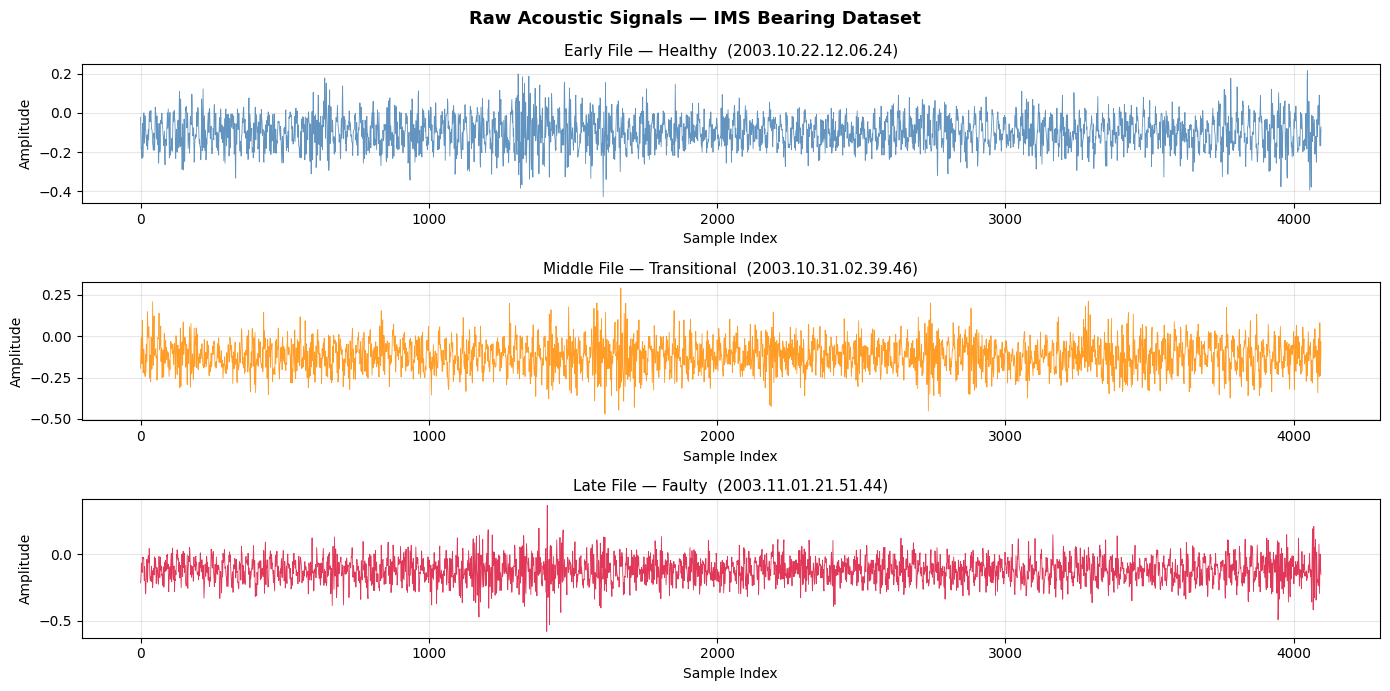

✅ Data understanding complete.


In [5]:
print('=' * 55)
print('      DATASET SUMMARY')
print('=' * 55)
print(f'  Total files loaded        : {len(signals)}')
print(f'  Samples per file (min)    : {min(s.shape[0] for s in signals)}')
print(f'  Samples per file (max)    : {max(s.shape[0] for s in signals)}')
print(f'  Samples per file (mean)   : {np.mean([s.shape[0] for s in signals]):.0f}')

# Signal statistics for first, middle, last file
for label, idx in [('First (Healthy)', 0),
                   ('Middle',          len(signals)//2),
                   ('Last  (Faulty)',  -1)]:
    s = signals[idx]
    print(f'\n  [{label}]')
    print(f'    File    : {filenames[idx]}')
    print(f'    Mean    : {s.mean():.4f}')
    print(f'    Std     : {s.std():.4f}')
    print(f'    Min/Max : {s.min():.4f} / {s.max():.4f}')

# ── Plot raw acoustic signals ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=False)
indices = [0, len(signals)//2, len(signals)-1]
titles  = ['Early File — Healthy', 'Middle File — Transitional', 'Late File — Faulty']
colors  = ['steelblue', 'darkorange', 'crimson']

for ax, idx, title, color in zip(axes, indices, titles, colors):
    s = signals[idx][:4096]         # show first 4096 samples
    ax.plot(s, color=color, linewidth=0.6, alpha=0.85)
    ax.set_title(f'{title}  ({filenames[idx]})', fontsize=11)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

plt.suptitle('Raw Acoustic Signals — IMS Bearing Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Data understanding complete.')

---
## Data Cleaning & Preprocessing
Steps: handle NaNs → optional bandpass filter → Z-score normalization → outlier clipping.

Preprocessing signals...
✅ Preprocessing done.
   Example — raw  std: 0.0811
   Example — clean std: 0.9981


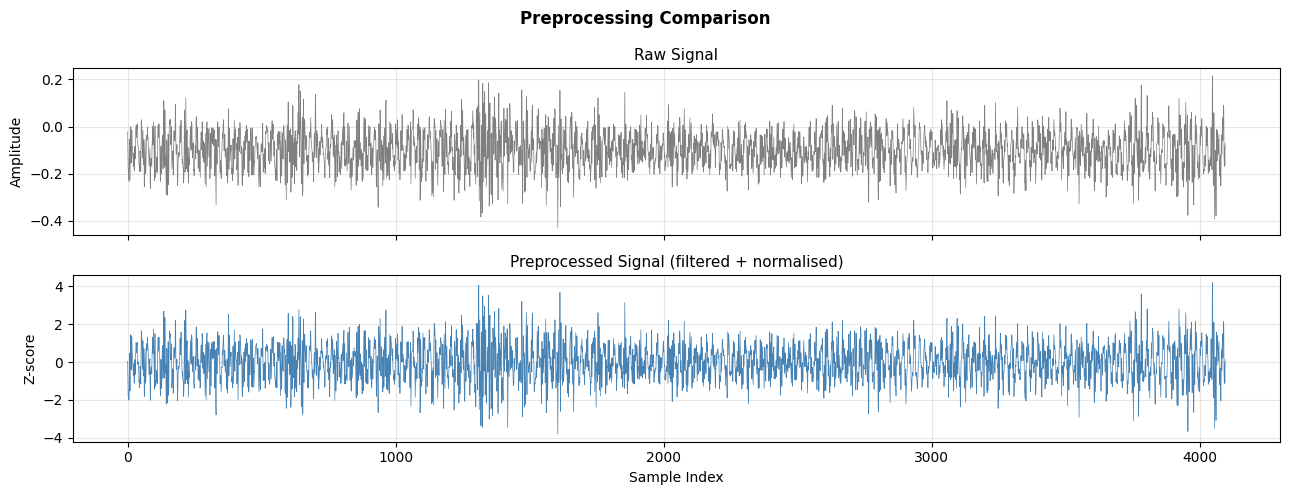

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
FS             = 20_000   # Sampling frequency (Hz) — IMS dataset standard
APPLY_FILTER   = True     # Set False to skip bandpass filtering
LOWCUT         = 500      # Bandpass low cutoff (Hz)
HIGHCUT        = 9_000    # Bandpass high cutoff (Hz)
OUTLIER_CLIP   = 5.0      # Clip values beyond ±5 std deviations


def bandpass_filter(sig, lowcut, highcut, fs, order=4):
    """Apply a Butterworth bandpass filter to isolate bearing frequencies."""
    nyq  = 0.5 * fs
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, sig)


def preprocess_signal(sig, fs=FS, apply_filter=APPLY_FILTER,
                      lowcut=LOWCUT, highcut=HIGHCUT, clip_std=OUTLIER_CLIP):
    """
    Full preprocessing pipeline for one signal:
      1. Replace NaN/Inf with interpolated values
      2. Optional bandpass filter
      3. Z-score normalisation
      4. Outlier clipping
    """
    s = sig.copy().astype(np.float32)

    # Step 1 — Handle missing / infinite values via linear interpolation
    bad_mask = ~np.isfinite(s)
    if bad_mask.any():
        idx       = np.arange(len(s))
        good_idx  = idx[~bad_mask]
        s[bad_mask] = np.interp(idx[bad_mask], good_idx, s[good_idx])

    # Step 2 — Bandpass filter (retains meaningful bearing frequencies)
    if apply_filter and len(s) > 100:
        try:
            s = bandpass_filter(s, lowcut, highcut, fs)
        except Exception:
            pass  # skip filter if signal is too short

    # Step 3 — Z-score normalisation (zero mean, unit variance)
    std = s.std()
    if std > 1e-8:
        s = (s - s.mean()) / std

    # Step 4 — Clip outliers beyond ±clip_std
    s = np.clip(s, -clip_std, clip_std)

    return s


# Apply preprocessing to all signals
print('Preprocessing signals...')
clean_signals = [preprocess_signal(s) for s in signals]

print(f'✅ Preprocessing done.')
print(f'   Example — raw  std: {signals[0].std():.4f}')
print(f'   Example — clean std: {clean_signals[0].std():.4f}')

# Quick before/after comparison plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
ax1.plot(signals[0][:4096], color='gray',    linewidth=0.5)
ax1.set_title('Raw Signal',                  fontsize=11)
ax1.set_ylabel('Amplitude')
ax2.plot(clean_signals[0][:4096], color='steelblue', linewidth=0.5)
ax2.set_title('Preprocessed Signal (filtered + normalised)', fontsize=11)
ax2.set_ylabel('Z-score')
ax2.set_xlabel('Sample Index')
for ax in (ax1, ax2): ax.grid(True, alpha=0.3)
plt.suptitle('Preprocessing Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Signal Windowing (Feature Preparation)
Segment each signal into fixed-length windows. This ensures every CNN input has the same size and also multiplies our training samples.

In [ ]:
# ── Window parameters ────────────────────────────────────────────────────────
WINDOW_SIZE = 2048    # samples per window (≈0.1 s at 20 kHz)
HOP_SIZE    = 1024    # overlap = WINDOW_SIZE - HOP_SIZE  (50% overlap)


def segment_signal(sig, window_size=WINDOW_SIZE, hop_size=HOP_SIZE):
    """
    Split a 1-D signal into overlapping windows.
    Returns an array of shape (num_windows, window_size).
    """
    segments = []
    start = 0
    while start + window_size <= len(sig):
        segments.append(sig[start : start + window_size])
        start += hop_size
    return np.array(segments, dtype=np.float32)


# Segment all signals and record which file each window came from
all_windows    = []   # list of shape-(num_windows, window_size) arrays
file_index_map = []   # which file each window belongs to

for i, sig in enumerate(clean_signals):
    wins = segment_signal(sig)
    all_windows.append(wins)
    file_index_map.extend([i] * len(wins))

file_index_map = np.array(file_index_map)

print(f'Window size  : {WINDOW_SIZE} samples')
print(f'Hop size     : {HOP_SIZE} samples  ({100*(1-HOP_SIZE/WINDOW_SIZE):.0f}% overlap)')
print(f'\nTotal windows created : {sum(len(w) for w in all_windows)}')
print(f'Windows from first file : {len(all_windows[0])}')
print(f'Each window shape       : {all_windows[0][0].shape}')
print('✅ Windowing complete.')

Window size  : 2048 samples
Hop size     : 1024 samples  (50% overlap)

Total windows created : 9500
Windows from first file : 19
Each window shape       : (2048,)
✅ Windowing complete.


---
## STFT Spectrogram Generation (Feature Extraction)
Convert each window into a spectrogram image using Short-Time Fourier Transform.

Generating spectrograms...  (may take 1–3 min for large datasets)
  Processed 50/500 files...
  Processed 100/500 files...
  Processed 150/500 files...
  Processed 200/500 files...
  Processed 250/500 files...
  Processed 300/500 files...
  Processed 350/500 files...
  Processed 400/500 files...
  Processed 450/500 files...
  Processed 500/500 files...

✅ Spectrogram generation complete.
   Total spectrograms : 9500
   Shape per image    : (64, 64)
   Value range        : [0.000, 0.954]


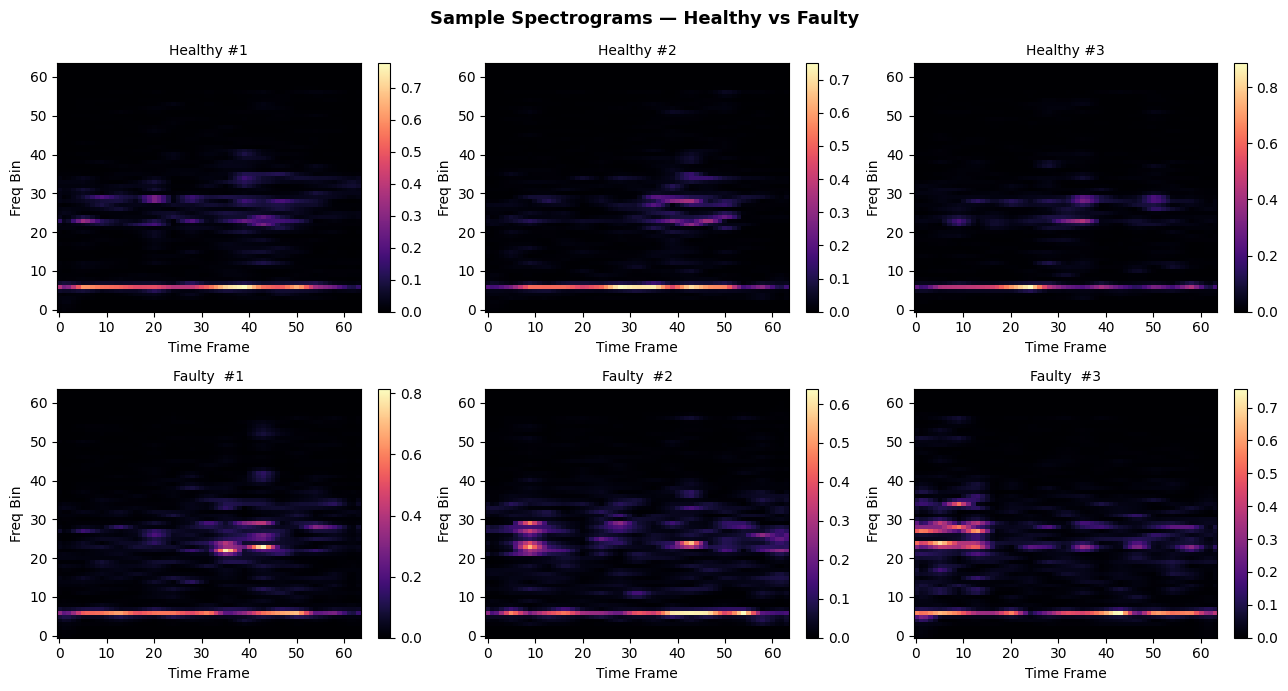

In [ ]:
from scipy.signal import stft as scipy_stft
from skimage.transform import resize as sk_resize  # for consistent image size

# Install skimage if missing
try:
    from skimage.transform import resize as sk_resize
except ImportError:
    !pip install -q scikit-image
    from skimage.transform import resize as sk_resize

# ── Spectrogram parameters ────────────────────────────────────────────────────
NPERSEG      = 256    # FFT window length (controls freq resolution)
NOVERLAP     = 128    # overlap between FFT windows (50%)
SPEC_H       = 64     # target spectrogram height (freq bins)
SPEC_W       = 64     # target spectrogram width  (time frames)


def window_to_spectrogram(win, fs=FS, nperseg=NPERSEG,
                           noverlap=NOVERLAP, h=SPEC_H, w=SPEC_W):
    """
    Convert a 1-D signal window into a normalised log-magnitude spectrogram.

    Steps:
      1. STFT  →  complex frequency-time representation
      2. |·|²  →  power spectrogram
      3. log(1 + S)  →  log-scale (compresses dynamic range)
      4. min-max normalise  →  values in [0, 1]
      5. resize  →  consistent (h × w) image
    """
    _, _, Zxx = scipy_stft(win, fs=fs, nperseg=nperseg,
                            noverlap=noverlap, window='hann')
    spec = np.abs(Zxx) ** 2                         # power spectrogram
    spec = np.log1p(spec)                           # log scale

    # Min-max normalise to [0, 1]
    s_min, s_max = spec.min(), spec.max()
    if s_max - s_min > 1e-8:
        spec = (spec - s_min) / (s_max - s_min)
    else:
        spec = np.zeros_like(spec)

    # Resize to target dimensions
    spec = sk_resize(spec, (h, w), anti_aliasing=True).astype(np.float32)
    return spec


# Generate spectrograms for every window (this may take a moment)
print('Generating spectrograms...  (may take 1–3 min for large datasets)')
spectrograms  = []   # each entry: shape (SPEC_H, SPEC_W)
file_ids      = []   # which file this spectrogram came from

for file_i, wins in enumerate(all_windows):
    for win in wins:
        sp = window_to_spectrogram(win)
        spectrograms.append(sp)
        file_ids.append(file_i)

    if (file_i + 1) % 50 == 0:
        print(f'  Processed {file_i+1}/{len(all_windows)} files...')

spectrograms = np.array(spectrograms, dtype=np.float32)   # (N, H, W)
file_ids     = np.array(file_ids)

print(f'\n✅ Spectrogram generation complete.')
print(f'   Total spectrograms : {spectrograms.shape[0]}')
print(f'   Shape per image    : {spectrograms.shape[1:]}')
print(f'   Value range        : [{spectrograms.min():.3f}, {spectrograms.max():.3f}]')

# ── Visualise sample spectrograms ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
n_files  = len(all_windows)
examples = {
    'Healthy #1' : np.where(file_ids == 0)[0][0],
    'Healthy #2' : np.where(file_ids == 2)[0][0],
    'Healthy #3' : np.where(file_ids == 4)[0][0],
    'Faulty  #1' : np.where(file_ids == n_files-1)[0][0],
    'Faulty  #2' : np.where(file_ids == n_files-2)[0][0],
    'Faulty  #3' : np.where(file_ids == n_files-3)[0][0],
}

for ax, (title, idx) in zip(axes.flatten(), examples.items()):
    im = ax.imshow(spectrograms[idx], aspect='auto',
                   origin='lower', cmap='magma')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Time Frame')
    ax.set_ylabel('Freq Bin')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Sample Spectrograms — Healthy vs Faulty', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Label Creation & Dataset Formatting
Assign binary labels based on file order, then format spectrograms for CNN input.

Total files         : 500
Healthy files (0–175) : 175
Excluded  files     : 150
Faulty  files (325–500) : 175

After filtering:
  X shape    : (6650, 64, 64, 1)   (samples, H, W, channel)
  y shape    : (6650,)
  Class 0 (Healthy) : 3325
  Class 1 (Faulty)  : 3325


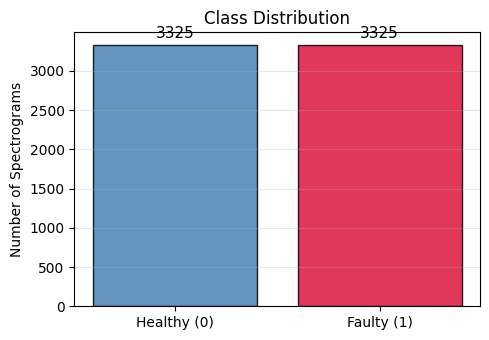

✅ Labels and X/y arrays ready.


In [ ]:
# ── Label thresholds ─────────────────────────────────────────────────────────
HEALTHY_FRAC = 0.35   # first 35% of files = Healthy (0)
FAULTY_FRAC  = 0.35   # last  35% of files = Faulty  (1)
# Files in between are excluded to create a cleaner boundary

n_files         = len(all_windows)
healthy_cutoff  = int(n_files * HEALTHY_FRAC)
faulty_start    = int(n_files * (1 - FAULTY_FRAC))

print(f'Total files         : {n_files}')
print(f'Healthy files (0–{healthy_cutoff}) : {healthy_cutoff}')
print(f'Excluded  files     : {faulty_start - healthy_cutoff}')
print(f'Faulty  files ({faulty_start}–{n_files}) : {n_files - faulty_start}')

# Create label vector — exclude middle (transitional) zone
labels_per_spec = np.full(len(file_ids), -1, dtype=np.int8)  # -1 = excluded
labels_per_spec[file_ids < healthy_cutoff]   = 0   # Healthy
labels_per_spec[file_ids >= faulty_start]    = 1   # Faulty

# Keep only labeled samples
keep_mask  = labels_per_spec >= 0
X_all      = spectrograms[keep_mask]
y_all      = labels_per_spec[keep_mask]

# ── Add channel dimension for CNN: (N, H, W) → (N, H, W, 1) ────────────────
X_all = X_all[..., np.newaxis]   # grayscale channel

print(f'\nAfter filtering:')
print(f'  X shape    : {X_all.shape}   (samples, H, W, channel)')
print(f'  y shape    : {y_all.shape}')
print(f'  Class 0 (Healthy) : {(y_all==0).sum()}')
print(f'  Class 1 (Faulty)  : {(y_all==1).sum()}')

# Class balance bar chart
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = [(y_all==0).sum(), (y_all==1).sum()]
bars = ax.bar(['Healthy (0)', 'Faulty (1)'], counts,
               color=['steelblue', 'crimson'], edgecolor='black', alpha=0.85)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(cnt), ha='center', va='bottom', fontsize=11)
ax.set_title('Class Distribution', fontsize=12)
ax.set_ylabel('Number of Spectrograms')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print('✅ Labels and X/y arrays ready.')

---
## Train / Validation / Test Split

In [ ]:
TEST_SIZE  = 0.15   # 15% for final test
VAL_SIZE   = 0.15   # 15% of total for validation

# First split: train+val vs test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_all
)

# Second split: train vs val
val_ratio = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_ratio,
    random_state=SEED,
    stratify=y_trainval
)

print('Split Summary')
print('=' * 45)
for split, X, y in [('Train',      X_train, y_train),
                    ('Validation', X_val,   y_val),
                    ('Test',       X_test,  y_test)]:
    h = (y==0).sum()
    f = (y==1).sum()
    print(f'  {split:12s}: {len(X):5d} samples  |  Healthy={h}  Faulty={f}')

print(f'\n  Input shape : {X_train.shape[1:]}  (H × W × C)')
print('✅ Data split complete.')

Split Summary
  Train       :  4654 samples  |  Healthy=2327  Faulty=2327
  Validation  :   998 samples  |  Healthy=499  Faulty=499
  Test        :   998 samples  |  Healthy=499  Faulty=499

  Input shape : (64, 64, 1)  (H × W × C)
✅ Data split complete.


---
## CNN Model Architecture

In [ ]:
def build_cnn(input_shape=(SPEC_H, SPEC_W, 1)):
    """
    CNN for binary spectrogram classification.

    Architecture:
        Input  (H, W, 1)
          ↓
        Conv2D(32, 3×3, ReLU)  →  BatchNorm  →  MaxPool(2×2)
          ↓
        Conv2D(64, 3×3, ReLU)  →  BatchNorm  →  MaxPool(2×2)
          ↓
        Conv2D(128, 3×3, ReLU) →  BatchNorm  →  MaxPool(2×2)
          ↓
        Flatten
          ↓
        Dense(256, ReLU)  →  Dropout(0.5)
          ↓
        Dense(1, Sigmoid)    ← output probability
    """
    model = models.Sequential(name='BearingFaultCNN')

    # ── Block 1 ──────────────────────────────────────────────────────────────
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                             padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Block 2 ──────────────────────────────────────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Block 3 ──────────────────────────────────────────────────────────────
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Classifier head ──────────────────────────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))   # binary output

    return model


model = build_cnn(input_shape=(SPEC_H, SPEC_W, 1))
model.summary()

# Count trainable parameters
total_params = model.count_params()
print(f'\nTotal parameters : {total_params:,}')
print('✅ Model built.')

Model: "BearingFaultCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,191,233 (8.36 MB)

 Trainable params: 2,190,785 (8.36 MB)

 Non-trainable params: 448 (1.75 KB)


Total parameters : 2,191,233
✅ Model built.


---
##  Compile the Model

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)
print('✅ Model compiled.')
print('   Loss      : binary_crossentropy')
print('   Optimizer : Adam (lr=1e-3)')
print('   Metrics   : accuracy, precision, recall, AUC')

✅ Model compiled.
   Loss      : binary_crossentropy
   Optimizer : Adam (lr=1e-3)
   Metrics   : accuracy, precision, recall, AUC


---
## Model Training

In [ ]:
EPOCHS     = 50
BATCH_SIZE = 32

# ── Callbacks ────────────────────────────────────────────────────────────────
cb_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

cb_checkpoint = callbacks.ModelCheckpoint(
    '/content/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

# ── Train ─────────────────────────────────────────────────────────────────────
print(f'Training for up to {EPOCHS} epochs (batch size={BATCH_SIZE})...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

print(f'\n✅ Training complete.')
print(f'   Epochs run        : {len(history.history["loss"])}')
print(f'   Best val_accuracy : {max(history.history["val_accuracy"]):.4f}')

Training for up to 50 epochs (batch size=32)...
Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 19s 70ms/step - accuracy: 0.7802 - auc: 0.8142 - loss: 0.7544 - precision: 0.7685 - recall: 0.8019 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 5.9625 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8962 - auc: 0.9327 - loss: 0.2913 - precision: 0.8576 - recall: 0.9502 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 11.3936 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9100 - auc: 0.9598 - loss: 0.2322 - precision: 0.8762 - recall: 0.9549 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 10.1561 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9175 - auc: 0.9725 - loss: 0.1953 - precision: 0.8744 - recall: 0.9751 - val_accurac

---
## CNN-LSTM Hybrid Model for RUL Prediction
Build a combined CNN-LSTM architecture where CNN extracts spatial features and LSTM learns temporal degradation patterns.


In [ ]:
# ── Sequence Parameters ───────────────────────────────────────────────────────
# For LSTM, we need sequences of spectrograms showing degradation over time
SEQUENCE_LENGTH = 10  # Number of consecutive spectrograms per sequence
STRIDE          = 5   # Number of samples to skip between sequences (overlap control)

def create_sequences_simple(X, y, sequence_length=SEQUENCE_LENGTH, stride=STRIDE):
    """
    Create temporal sequences from spectrograms.
    Each sequence represents consecutive time windows showing degradation progression.
    
    Returns:
        X_seq: array of shape (num_sequences, sequence_length, 64, 64, 1)
        y_seq: array of shape (num_sequences,) - RUL targets
    """
    X_sequences = []
    y_sequences = []
    
    # Create overlapping sequences with specified stride
    for start_idx in range(0, len(X) - sequence_length + 1, stride):
        end_idx = start_idx + sequence_length
        X_seq = X[start_idx:end_idx]  # (sequence_length, 64, 64, 1)
        
        # RUL target: Use health status at end of sequence
        # Healthy (y=0) → high RUL ~10, Faulty (y=1) → low RUL ~1
        rul = 10 - (y[end_idx-1] * 9)  # Simple mapping, replace with real RUL if available
        
        X_sequences.append(X_seq)
        y_sequences.append(rul)
    
    return np.array(X_sequences), np.array(y_sequences)

print('Creating temporal sequences for LSTM...')
X_train_seq, y_train_seq = create_sequences_simple(X_train, y_train)
X_val_seq, y_val_seq     = create_sequences_simple(X_val, y_val)
X_test_seq, y_test_seq   = create_sequences_simple(X_test, y_test)

print(f'✅ Sequences created successfully!')
print(f'   Train sequences: {X_train_seq.shape}  (batches, time steps, height, width, channels)')
print(f'   Val sequences  : {X_val_seq.shape}')
print(f'   Test sequences : {X_test_seq.shape}')
print(f'   RUL targets    : {y_train_seq.shape}')
print(f'   RUL range      : [{y_train_seq.min():.2f}, {y_train_seq.max():.2f}]')


In [ ]:
metrics = model.evaluate(X_test, y_test, verbose=0, return_dict=True)

print("\n📊 Final Test Metrics")
print("="*30)

for key, value in metrics.items():
    print(f"{key:12s}: {value:.4f}")


📊 Final Test Metrics
accuracy    : 0.9178
auc         : 0.9883
loss        : 0.2339
precision   : 0.8651
recall      : 0.9900


---
## Training Curves Visualization

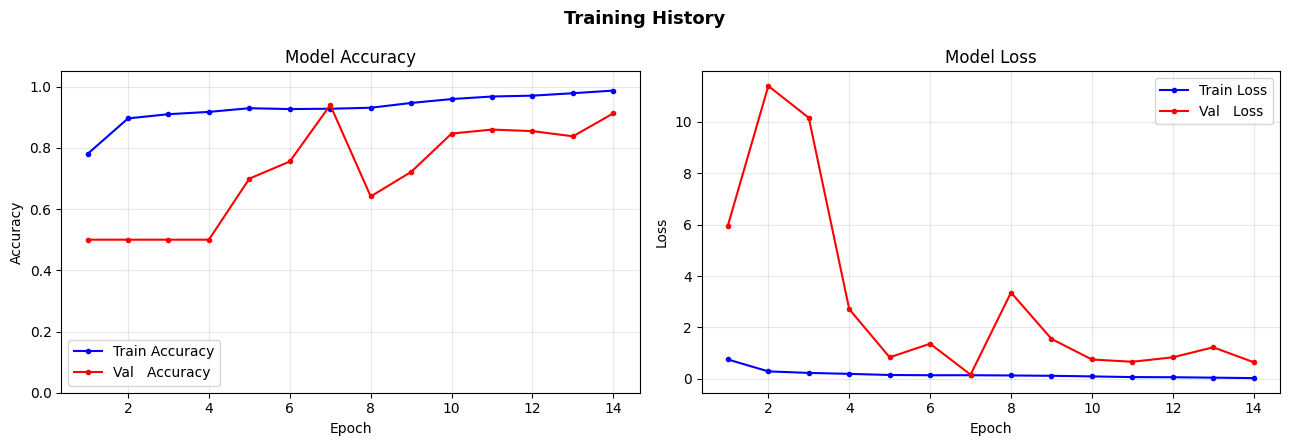

✅ Training curves plotted.


In [ ]:
def plot_training_history(hist):
    """Plot accuracy and loss curves for training and validation sets."""
    epochs = range(1, len(hist.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # ── Accuracy ──────────────────────────────────────────────────────────────
    axes[0].plot(epochs, hist.history['accuracy'],     'b-o', markersize=3,
                 label='Train Accuracy')
    axes[0].plot(epochs, hist.history['val_accuracy'], 'r-o', markersize=3,
                 label='Val   Accuracy')
    axes[0].set_title('Model Accuracy', fontsize=12)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1.05])

    # ── Loss ─────────────────────────────────────────────────────────────────
    axes[1].plot(epochs, hist.history['loss'],         'b-o', markersize=3,
                 label='Train Loss')
    axes[1].plot(epochs, hist.history['val_loss'],     'r-o', markersize=3,
                 label='Val   Loss')
    axes[1].set_title('Model Loss', fontsize=12)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_training_history(history)
print('✅ Training curves plotted.')

---
## Model Evaluation on Test Set

Test Set Results
  loss         : 0.2339
  compile_metrics : 0.9178


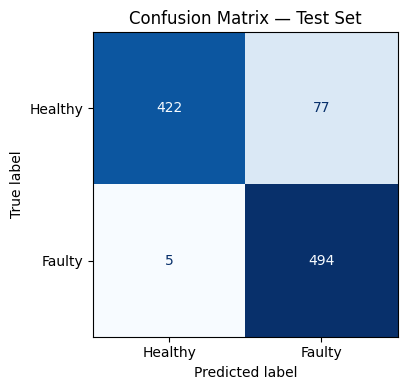


Classification Report
              precision    recall  f1-score   support

 Healthy (0)       0.99      0.85      0.91       499
 Faulty  (1)       0.87      0.99      0.92       499

    accuracy                           0.92       998
   macro avg       0.93      0.92      0.92       998
weighted avg       0.93      0.92      0.92       998

✅ Evaluation complete.


In [ ]:
# Load best checkpoint weights
model.load_weights('/content/best_model.keras')

# ── Evaluate on test set ──────────────────────────────────────────────────────
test_results = model.evaluate(X_test, y_test, verbose=0)
metric_names = model.metrics_names

print('Test Set Results')
print('=' * 40)
for name, val in zip(metric_names, test_results):
    print(f'  {name:12s} : {val:.4f}')

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_prob = model.predict(X_test, verbose=0).ravel()
y_pred      = (y_pred_prob >= 0.5).astype(int)

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Healthy', 'Faulty'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontsize=12)
plt.tight_layout()
plt.show()

# ── Classification report ────────────────────────────────────────────────────
print('\nClassification Report')
print('=' * 40)
print(classification_report(y_test, y_pred,
                              target_names=['Healthy (0)', 'Faulty  (1)']))
print('✅ Evaluation complete.')

---
## Prediction Results Visualization

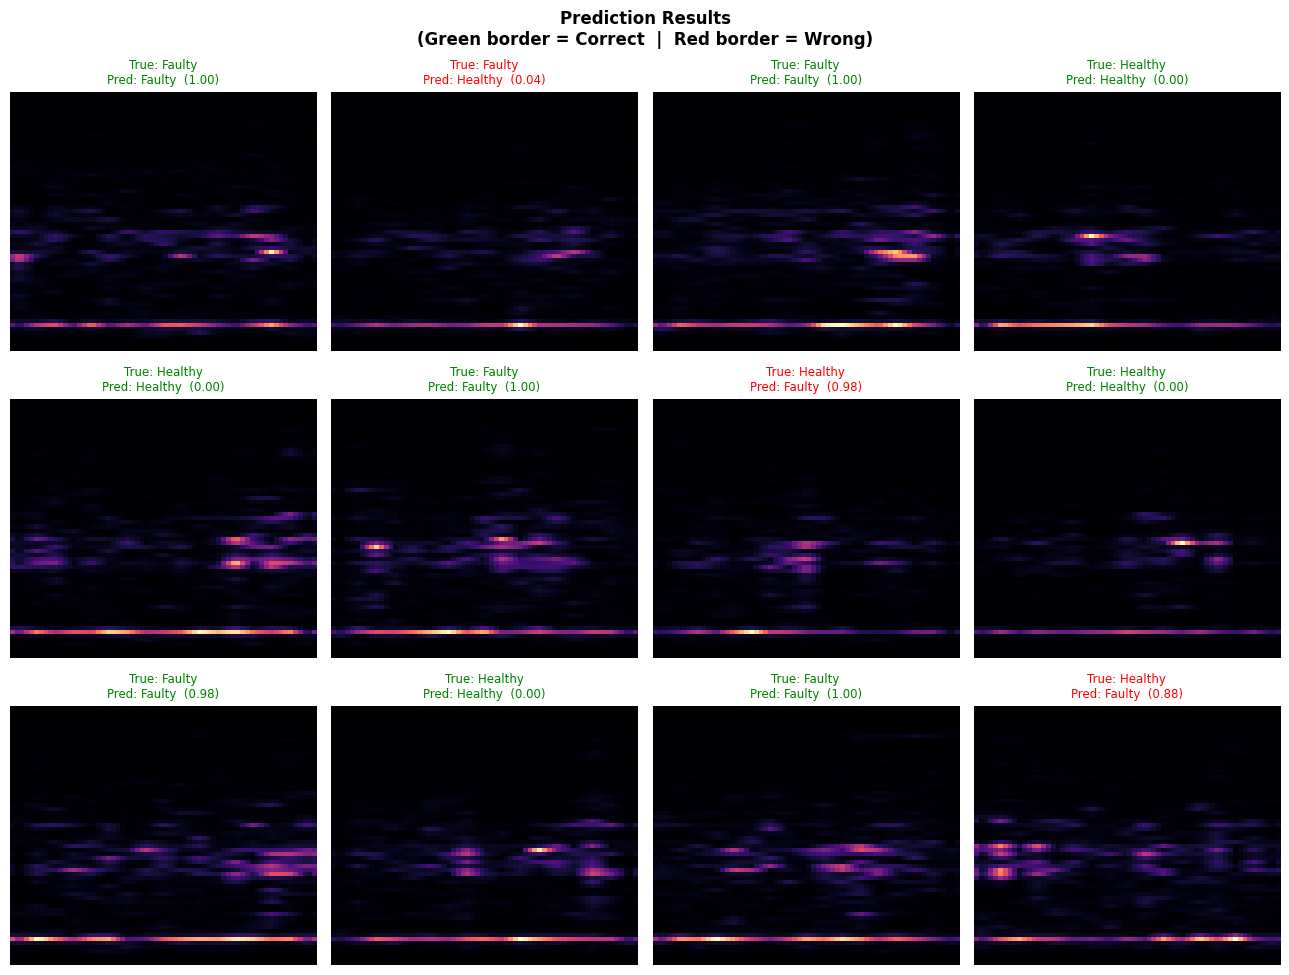

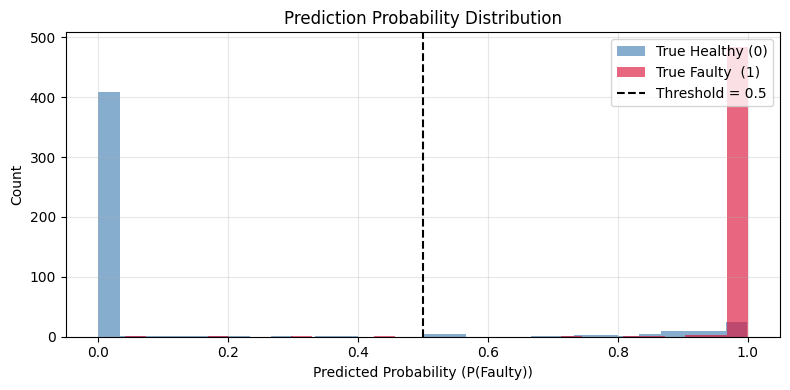

✅ Visualisations complete.


In [ ]:
def visualize_predictions(X, y_true, y_pred_prob, n=12, threshold=0.5):
    """
    Display a grid of spectrogram samples with:
      - True label (title)
      - Predicted probability bar
      - Green border = correct  |  Red border = wrong
    """
    y_pred  = (y_pred_prob >= threshold).astype(int)
    # Pick a mix of correct and incorrect predictions
    correct   = np.where(y_pred == y_true)[0]
    incorrect = np.where(y_pred != y_true)[0]

    n_correct   = min(n - min(3, len(incorrect)), len(correct))
    n_incorrect = min(n - n_correct, len(incorrect))

    indices = np.concatenate([
        np.random.choice(correct,   n_correct,   replace=False),
        np.random.choice(incorrect, n_incorrect, replace=False)
                              ]) if len(incorrect) > 0 else \
              np.random.choice(correct, n, replace=False)
    np.random.shuffle(indices)

    cols   = 4
    rows   = int(np.ceil(len(indices) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(13, rows * 3.3))
    axes = axes.flatten()

    label_map = {0: 'Healthy', 1: 'Faulty'}
    colors    = {0: 'steelblue', 1: 'crimson'}

    for ax, idx in zip(axes[:len(indices)], indices):
        ax.imshow(X[idx, :, :, 0], aspect='auto',
                  origin='lower', cmap='magma')

        true_lbl = y_true[idx]
        pred_lbl = y_pred[idx]
        prob     = y_pred_prob[idx]
        correct  = (true_lbl == pred_lbl)

        border_color = 'limegreen' if correct else 'red'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2.5)

        ax.set_title(
            f'True: {label_map[true_lbl]}\n'
            f'Pred: {label_map[pred_lbl]}  ({prob:.2f})',
            fontsize=8.5,
            color='green' if correct else 'red'
        )
        ax.axis('off')

    # Hide unused axes
    for ax in axes[len(indices):]:
        ax.axis('off')

    plt.suptitle('Prediction Results\n'
                 '(Green border = Correct  |  Red border = Wrong)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_predictions(X_test, y_test, y_pred_prob, n=12)

# ── Prediction probability distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_pred_prob[y_test == 0], bins=30, alpha=0.65,
        color='steelblue', label='True Healthy (0)')
ax.hist(y_pred_prob[y_test == 1], bins=30, alpha=0.65,
        color='crimson',   label='True Faulty  (1)')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
ax.set_xlabel('Predicted Probability (P(Faulty))')
ax.set_ylabel('Count')
ax.set_title('Prediction Probability Distribution', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('✅ Visualisations complete.')

---
## Predict on New / Sample Inputs

In [ ]:
def predict_single_spectrogram(spec_2d, threshold=0.5):
    """
    Predict fault status for a single spectrogram image.

    Parameters
    ----------
    spec_2d   : np.ndarray  — shape (H, W)  — normalised spectrogram
    threshold : float       — decision boundary

    Returns
    -------
    label : str   — 'Healthy' or 'Faulty'
    prob  : float — probability of being Faulty
    """
    x = spec_2d[np.newaxis, :, :, np.newaxis]   # (1, H, W, 1)
    prob  = float(model.predict(x, verbose=0)[0, 0])
    label = 'Faulty' if prob >= threshold else 'Healthy'
    return label, prob


def predict_from_raw_signal(raw_signal, channel=0, threshold=0.5):
    """
    End-to-end prediction directly from a raw acoustic signal.
    Applies the full preprocessing → windowing → STFT pipeline.
    Returns the majority-vote label across all windows.
    """
    # Preprocess
    clean = preprocess_signal(raw_signal)
    # Segment
    wins  = segment_signal(clean)
    if len(wins) == 0:
        return 'Error: signal too short', 0.0
    # Spectrogram per window
    specs = np.array([window_to_spectrogram(w) for w in wins])
    specs = specs[:, :, :, np.newaxis]           # (N, H, W, 1)
    # Batch predict
    probs = model.predict(specs, verbose=0).ravel()
    mean_prob = float(probs.mean())
    label = 'Faulty' if mean_prob >= threshold else 'Healthy'
    return label, mean_prob


# ── Demo: predict on 6 random test spectrograms ───────────────────────────────
print('Sample Predictions on Test Set')
print('=' * 55)
print(f'{"#":<5} {"True Label":<15} {"Predicted":<12} {"P(Faulty)":<12} {"Correct?"}')
print('-' * 55)

sample_idx = np.random.choice(len(X_test), size=10, replace=False)
label_map  = {0: 'Healthy', 1: 'Faulty'}

for i, idx in enumerate(sample_idx):
    pred_label, prob = predict_single_spectrogram(X_test[idx, :, :, 0])
    true_label       = label_map[y_test[idx]]
    correct_sym      = '✅' if pred_label == true_label else '❌'
    print(f'{i+1:<5} {true_label:<15} {pred_label:<12} {prob:<12.4f} {correct_sym}')

# ── Demo: full pipeline on a raw file ────────────────────────────────────────
print('\n\nEnd-to-End Pipeline Demo (raw signal → prediction)')
print('=' * 55)
for desc, file_i in [('Early (Healthy)', 0), ('Late (Faulty)', len(signals)-1)]:
    label, prob = predict_from_raw_signal(signals[file_i])
    icon = '🟢' if label == 'Healthy' else '🔴'
    print(f'  {icon}  File: {filenames[file_i]:<30}  '
          f'→  {label}  (P(Faulty)={prob:.4f})')

print('\n✅ Prediction demo complete.')

Sample Predictions on Test Set
#     True Label      Predicted    P(Faulty)    Correct?
-------------------------------------------------------
1     Healthy         Healthy      0.0000       ✅
2     Faulty          Faulty       0.9998       ✅
3     Faulty          Faulty       1.0000       ✅
4     Healthy         Healthy      0.0000       ✅
5     Healthy         Healthy      0.0000       ✅
6     Healthy         Healthy      0.0000       ✅
7     Healthy         Faulty       0.9597       ❌
8     Healthy         Healthy      0.0000       ✅
9     Faulty          Faulty       0.9992       ✅
10    Faulty          Faulty       0.9997       ✅


End-to-End Pipeline Demo (raw signal → prediction)
  🟢  File: 2003.10.22.12.06.24             →  Healthy  (P(Faulty)=0.0000)
  🔴  File: 2003.11.01.21.51.44             →  Faulty  (P(Faulty)=0.9962)

✅ Prediction demo complete.


In [ ]:
SAVE_DIR = '/content/drive/MyDrive/IMS_Bearing/saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save full model (architecture + weights + optimizer state)
model_path = os.path.join(SAVE_DIR, 'bearing_fault_cnn.keras')
model.save(model_path)

print(f'✅ Model saved to: {model_path}')
print('\nTo reload later:')
print(f'  model = tf.keras.models.load_model("{model_path}")')

✅ Model saved to: /content/drive/MyDrive/IMS_Bearing/saved_model/bearing_fault_cnn.keras

To reload later:
  model = tf.keras.models.load_model("/content/drive/MyDrive/IMS_Bearing/saved_model/bearing_fault_cnn.keras")
